# Football Penalty Analysis (2020-2025)

This notebook analyzes penalty kick data to understand factors affecting penalty success rates.

In [2]:
import kagglehub

# Download penalty kick dataset from Kaggle
path = kagglehub.dataset_download("rodrigoarede2003/penalty-kick-dataset-20202025")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yassi\.cache\kagglehub\datasets\rodrigoarede2003\penalty-kick-dataset-20202025\versions\2


## 1. Data Loading

Download and load the penalty kick dataset from Kaggle.

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel(path + "/real_data.xlsx")
df.head()

,Unnamed: 0,Country,player_id,player_name,Kicker_Foot,Kicker_Side,Goalie_Side,Outcome,goalkeer_name,goalkeeper_id,Home_Goals,Away_Goals,Minute,Team_Type,player_name.1,player_id.1,Unnamed: 16,goalkeer_name.1,goalkeeper_id.1
0,24/25,Portugal,1.0,Galeno,R,L,L,1.0,Andrew,1.0,0,0,30,H,Galeno,1.0,NaN,Andrew,1.0
1,24/25,Portugal,2.0,Namaso,R,L,R,1.0,Andrew,1.0,0,0,70,H,Namaso,2.0,NaN,Dani Figueira,2.0
2,24/25,Portugal,3.0,Safira,R,R,L,1.0,Dani Figueira,2.0,1,0,70,A,Safira,3.0,NaN,Ricardo Batista,3.0
3,24/25,Portugal,4.0,Reisinho,L,L,R,1.0,Ricardo Batista,3.0,0,0,77,A,Reisinho,4.0,NaN,Gabriel Batista,4.0
4,24/25,Portugal,1.0,Galeno,R,L,R,1.0,Gabriel Batista,4.0,1,0,25,A,Alan,5.0,NaN,Nico Mantl,5.0


## 2. Exploratory Analysis

### 2.1 Right-Footed Kickers: Success by Side

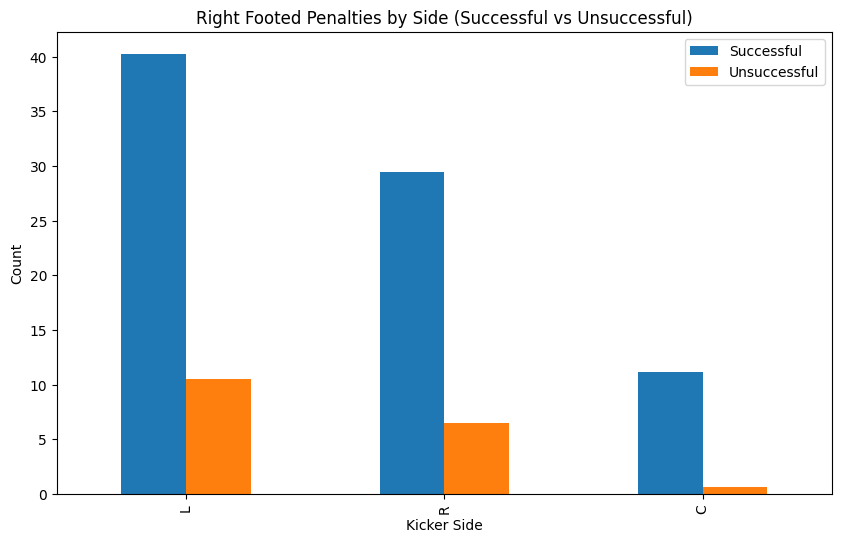

In [4]:
import matplotlib.pyplot as plt

# Calculate percentages for right-footed kickers
successful = 100 * df[(df["Kicker_Foot"] == "R") & (df["Outcome"] == 1)]["Kicker_Side"].value_counts() / len(df[(df["Kicker_Foot"] == "R")]["Kicker_Side"])
unsuccessful = 100 * df[(df["Kicker_Foot"] == "R") & (df["Outcome"] == 0)]["Kicker_Side"].value_counts() / len(df[(df["Kicker_Foot"] == "R")]["Kicker_Side"])

comparison = pd.DataFrame({
    "Successful": successful,
    "Unsuccessful": unsuccessful
}).fillna(0)

# Plot side-by-side comparison
comparison.plot(kind="bar", title="Right Footed Penalties by Side (Successful vs Unsuccessful)", figsize=(10, 6))
plt.xlabel("Kicker Side")
plt.ylabel("Count")
plt.show()

### 2.2 Feature Engineering: Score Context

Create features to capture the team's score situation (Leading, Trailing, or Tied) from their perspective.

In [5]:
# Create score context from team's perspective
df["score_diff"] = np.where(df["Team_Type"] == "H", df["Home_Goals"] - df["Away_Goals"], df["Away_Goals"] - df["Home_Goals"])
df["score"] = np.where(df["score_diff"] > 0, "Leading", np.where(df["score_diff"] < 0, "Trailing", "Tied"))

### 2.3 Success Rate by Score Context

Analyze how penalty success rates vary based on whether the team is leading, trailing, or tied.

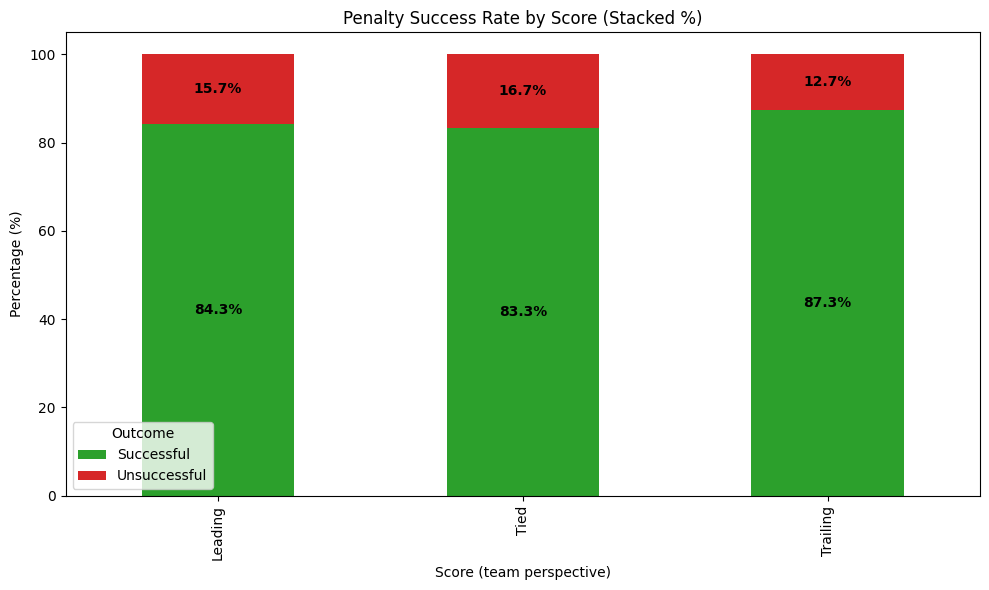

In [6]:
import matplotlib.pyplot as plt

# Count outcomes by score context
successful = df[df["Outcome"] == 1]["score"].value_counts() 
unsuccessful = df[df["Outcome"] == 0]["score"].value_counts() 

comparison = pd.DataFrame({
    "Successful": successful,
    "Unsuccessful": unsuccessful,
    "Total": successful + unsuccessful
}).fillna(0)

# Calculate percentage rates
comparison["successful_rate"] = comparison["Successful"] / comparison["Total"] * 100
comparison["unsuccessful_rate"] = comparison["Unsuccessful"] / comparison["Total"] * 100

# Plot stacked percentage bar chart
ax = comparison[["successful_rate", "unsuccessful_rate"]].plot(kind="bar", stacked=True, title="Penalty Success Rate by Score (Stacked %)", figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.xlabel("Score (team perspective)")
plt.ylabel("Percentage (%)")
plt.legend(title="Outcome", labels=["Successful", "Unsuccessful"])

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## 3. Temporal Analysis: Match Minute

Investigating whether penalty success rates change throughout the match due to fatigue or pressure.

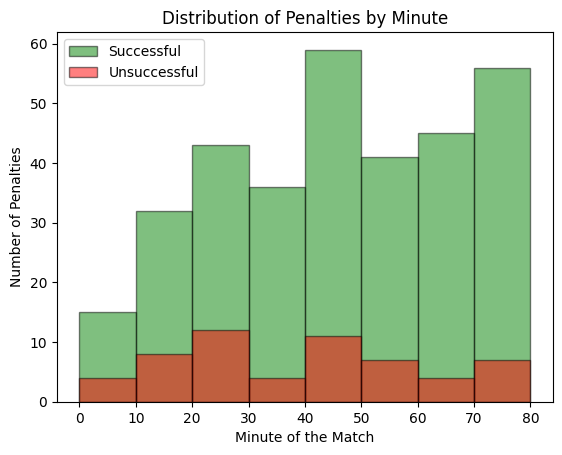

In [7]:
from matplotlib import pyplot as plt

# Plot histogram of penalty timing by outcome
bins = np.arange(0, 90, 10)
plt.hist(df[df["Outcome"] == 1]["Minute"], bins=bins, alpha=0.5, label="Successful", color='g', edgecolor='black')
plt.hist(df[df["Outcome"] == 0]["Minute"], bins=bins, alpha=0.5, label="Unsuccessful", color='r', edgecolor='black')
plt.xlabel("Minute of the Match")
plt.ylabel("Number of Penalties")
plt.title("Distribution of Penalties by Minute")
plt.legend()
plt.show()

### 3.1 Distribution of Penalties Over Time

In [8]:
# Group penalties by 10-minute intervals
bins = np.arange(0, 91, 10)
minute_bins = pd.cut(df["Minute"], bins=bins, right=False)

# Calculate success/failure rates per interval
penalty_stats = df.groupby(minute_bins)["Outcome"].agg(['count', 'sum'])
penalty_stats.columns = ['Total', 'Successful']
penalty_stats['Unsuccessful'] = penalty_stats['Total'] - penalty_stats['Successful']
penalty_stats['Successful Rate'] = penalty_stats['Successful'] / penalty_stats['Total'] * 100
penalty_stats['Unsuccessful Rate'] = penalty_stats['Unsuccessful'] / penalty_stats['Total'] * 100
penalty_stats.head(10)

C:\Users\yassi\AppData\Local\Temp\ipykernel_24228\3761794217.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  penalty_stats = df.groupby(minute_bins)["Outcome"].agg(['count', 'sum'])


,Total,Successful,Unsuccessful,Successful Rate,Unsuccessful Rate
Minute,,,,,
"[0, 10)",19,15.000000,4.000000,78.947368,21.052632
"[10, 20)",40,32.000000,8.000000,80.000000,20.000000
"[20, 30)",55,43.000000,12.000000,78.181818,21.818182
"[30, 40)",43,36.209028,6.790972,84.207041,15.792959
"[40, 50)",70,59.000000,11.000000,84.285714,15.714286
"[50, 60)",48,41.000000,7.000000,85.416667,14.583333
"[60, 70)",51,45.209722,5.790278,88.646514,11.353486
"[70, 80)",58,52.042361,5.957639,89.728209,10.271791
"[80, 90)",50,39.000000,11.000000,78.000000,22.000000


### 3.2 Success Rate by Time Interval

In [9]:
# H0: Miss probability is independent of match minute
# H1: Miss probability varies with match minute

from scipy.stats import chi2_contingency

table = penalty_stats[['Successful','Unsuccessful']].copy()
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square Statistic: {chi2}, degrees of freedom: {dof}, expected : \n{expected},\n p-value: {p}")

Chi-square Statistic: 5.661175993846787, degrees of freedom: 8, expected : 
[[15.86811316  3.13188684]
 [33.40655402  6.59344598]
 [45.93401178  9.06598822]
 [35.91204557  7.08795443]
 [58.46146953 11.53853047]
 [40.08786482  7.91213518]
 [42.59335637  8.40664363]
 [48.43950333  9.56049667]
 [41.75819252  8.24180748]],
 p-value: 0.6851250651129508


### 3.3 Chi-Square Test: Time Independence

Testing whether miss rate is independent of match minute.

**Result:** p-value = 0.68 > 0.05. We fail to reject H₀, meaning there's no evidence that miss rate changes over time (appears random).

### 3.4 Logistic Regression: Minute Effect

Modeling the probability of missing a penalty as a function of match minute.

In [10]:
import statsmodels.api as sm

# Prepare features for logistic regression
X = sm.add_constant(df['Minute'])
y = 1 - df['Outcome']  # 1 = miss, 0 = scored

# Fit model
model = sm.Logit(y, X).fit()
print(model.summary())
print("logit(P(miss)) = {:.4f} + {:.4f} * Minute".format(model.params['const'], model.params['Minute']))

Optimization terminated successfully.
         Current function value: 0.449812
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  482
Model:                          Logit   Df Residuals:                      480
Method:                           MLE   Df Model:                            1
Date:                Thu, 23 Oct 2025   Pseudo R-squ.:                0.001037
Time:                        22:43:32   Log-Likelihood:                -216.81
converged:                       True   LL-Null:                       -217.03
Covariance Type:            nonrobust   LLR p-value:                    0.5023
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4405      0.274     -5.259      0.000      -1.977      -0.904
Minute        -0.0032      0.

**Conclusion:** Minutes have a negligible effect on the probability of missing a penalty. Next, we'll examine whether score context (trailing) combined with time affects miss rates.

## 4. Pressure Analysis: Missed Penalties by Score Difference

Examining the distribution of score differences when penalties are missed to understand pressure situations.

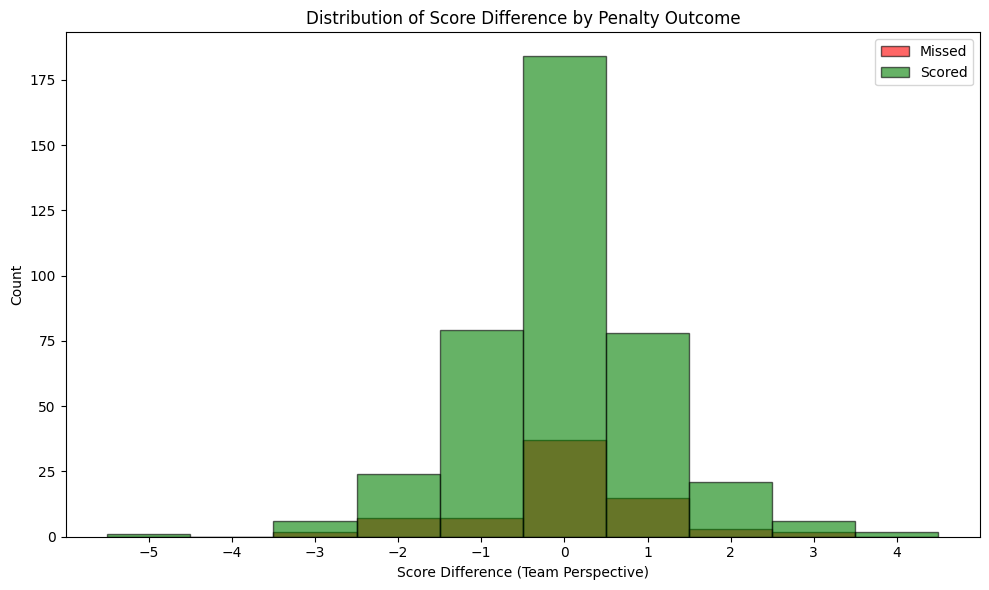

In [12]:
# Filter penalties by outcome
part_df = df[['Minute', 'Outcome', "score_diff"]]
df_missed = part_df[part_df["Outcome"] == 0]
df_goal = part_df[part_df["Outcome"] == 1]

# Plot overlapping histograms with integer bins
plt.figure(figsize=(10, 6))
bins = np.arange(part_df['score_diff'].min() - 0.5, part_df['score_diff'].max() + 1.5, 1)
plt.hist(df_missed['score_diff'], bins=bins, alpha=0.6, color='red', edgecolor='black', label='Missed')
plt.hist(df_goal['score_diff'], bins=bins, alpha=0.6, color='g', edgecolor='black', label='Scored')
plt.xlabel('Score Difference (Team Perspective)')
plt.ylabel('Count')
plt.title('Distribution of Score Difference by Penalty Outcome')
plt.legend()
plt.xticks(range(int(part_df['score_diff'].min()), int(part_df['score_diff'].max()) + 1))
plt.tight_layout()
plt.show()